In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import re


In [2]:
# Define the results directory
results_base_dir = Path("production-results/Results")

# Function to extract scenario information from directory name and docker-compose
def parse_scenario_info(scenario_dir):
    """Extract architecture type, device count, and total node count from scenario directory."""
    dir_name = scenario_dir.name
    
    # Read docker-compose to get D2D flag and device count
    docker_compose_path = scenario_dir / "docker-compose.yml"
    if not docker_compose_path.exists():
        return None
    
    with open(docker_compose_path, 'r') as f:
        content = f.read()
        
    # Find first client definition to extract D2D and DEVICE_COUNT
    d2d_match = re.search(r'D2D:\s*"(True|False)"', content)
    device_count_match = re.search(r'DEVICE_COUNT:\s*"(\d+)"', content)
    
    if not d2d_match or not device_count_match:
        return None
    
    is_d2d = d2d_match.group(1) == "True"
    device_count = int(device_count_match.group(1))
    architecture = "D2D" if is_d2d else "Centralized"
    
    # Count total nodes (clients + edges + servers)
    node_pattern = re.compile(r'^  (client\d+|edge\d+|server\d+):', re.MULTILINE)
    total_nodes = len(node_pattern.findall(content))
    
    # Find CSV file
    csv_files = list(scenario_dir.glob("results-*.csv"))
    if not csv_files:
        return None
    
    return {
        'dir_name': dir_name,
        'path': scenario_dir,
        'architecture': architecture,
        'device_count': device_count,
        'total_nodes': total_nodes,
        'csv_file': csv_files[0]
    }

# Scan all scenario directories
scenarios = []
if results_base_dir.exists():
    for scenario_dir in results_base_dir.iterdir():
        if scenario_dir.is_dir():
            info = parse_scenario_info(scenario_dir)
            if info:
                scenarios.append(info)

# Display found scenarios
print("Found scenarios:")
for scenario in scenarios:
    print(f"  - {scenario['architecture']:12s} | {scenario['total_nodes']:2d} nodes | {scenario['device_count']:2d} devices | {scenario['dir_name']}")

# Group scenarios by total node count (not device count)
from collections import defaultdict
scenarios_by_nodes = defaultdict(list)
for scenario in scenarios:
    scenarios_by_nodes[scenario['total_nodes']].append(scenario)

print(f"\nScenarios grouped by total node count:")
for node_count, scen_list in sorted(scenarios_by_nodes.items()):
    architectures = [s['architecture'] for s in scen_list]
    print(f"  {node_count} nodes: {', '.join(architectures)}")


Found scenarios:
  - Centralized  | 37 nodes | 30 devices | 2025-11-24 14:43 Centralized  6 30 Offloading
  - Centralized  | 19 nodes | 15 devices | 2025-11-24 13:32 Centralized  3 15 Offloading
  - D2D          | 37 nodes | 36 devices | 2025-11-24 14:03 Centralized D2D 1 36 Offloading
  - D2D          | 19 nodes | 18 devices | 2025-11-24 13:06 Centralized D2D 1 18 Offloading

Scenarios grouped by total node count:
  19 nodes: Centralized, D2D
  37 nodes: Centralized, D2D


In [3]:
# Function to load and prepare data from CSV
def load_scenario_data(csv_path):
    """Load scenario results from CSV file."""
    df = pd.read_csv(csv_path)
    return df

# Function to plot comparison for scenarios with same total node count
def plot_comparison(d2d_scenario, centralized_scenario):
    """Plot accuracy over time comparison between D2D and Centralized architectures."""
    
    # Load data
    d2d_data = load_scenario_data(d2d_scenario['csv_file'])
    centralized_data = load_scenario_data(centralized_scenario['csv_file'])
    
    # Create figure
    plt.figure(figsize=(14, 7))
    
    # Plot D2D
    plt.plot(d2d_data['Round'], d2d_data['Accuracy (%)'], 
             marker='o', markersize=3, linewidth=2.5, 
             label=f"D2D ({d2d_scenario['device_count']} clients)", 
             color='#2E86AB', alpha=0.8)
    
    # Plot Centralized
    plt.plot(centralized_data['Round'], centralized_data['Accuracy (%)'], 
             marker='s', markersize=3, linewidth=2.5,
             label=f"Centralized ({centralized_scenario['device_count']} clients)", 
             color='#A23B72', alpha=0.8)
    
    # Formatting
    plt.xlabel('Round', fontsize=13, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
    plt.title(f'Model Accuracy Over Time: D2D vs Centralized\n({d2d_scenario["total_nodes"]} total nodes)', 
              fontsize=15, fontweight='bold', pad=20)
    plt.legend(fontsize=12, loc='lower right', framealpha=0.9)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Display statistics
    print(f"\n{'='*70}")
    print(f"Comparison: {d2d_scenario['total_nodes']} total nodes")
    print(f"{'='*70}")
    print(f"\nD2D Architecture ({d2d_scenario['device_count']} clients):")
    print(f"  - Initial Accuracy: {d2d_data['Accuracy (%)'].iloc[0]:.2f}%")
    print(f"  - Final Accuracy:   {d2d_data['Accuracy (%)'].iloc[-1]:.2f}%")
    print(f"  - Max Accuracy:     {d2d_data['Accuracy (%)'].max():.2f}%")
    print(f"  - Total Rounds:     {len(d2d_data)}")
    
    print(f"\nCentralized Architecture ({centralized_scenario['device_count']} clients):")
    print(f"  - Initial Accuracy: {centralized_data['Accuracy (%)'].iloc[0]:.2f}%")
    print(f"  - Final Accuracy:   {centralized_data['Accuracy (%)'].iloc[-1]:.2f}%")
    print(f"  - Max Accuracy:     {centralized_data['Accuracy (%)'].max():.2f}%")
    print(f"  - Total Rounds:     {len(centralized_data)}")
    
    print(f"\nDifference (Centralized - D2D):")
    print(f"  - Final Accuracy:   {centralized_data['Accuracy (%)'].iloc[-1] - d2d_data['Accuracy (%)'].iloc[-1]:+.2f}%")
    print(f"  - Max Accuracy:     {centralized_data['Accuracy (%)'].max() - d2d_data['Accuracy (%)'].max():+.2f}%")
    
    plt.show()



Creating comparison plot for scenarios with 19 total nodes
D2D:         2025-11-24 13:06 Centralized D2D 1 18 Offloading
Centralized: 2025-11-24 13:32 Centralized  3 15 Offloading

Comparison: 19 total nodes

D2D Architecture (18 clients):
  - Initial Accuracy: 29.99%
  - Final Accuracy:   78.55%
  - Max Accuracy:     78.92%
  - Total Rounds:     200

Centralized Architecture (15 clients):
  - Initial Accuracy: 29.99%
  - Final Accuracy:   70.26%
  - Max Accuracy:     70.43%
  - Total Rounds:     200

Difference (Centralized - D2D):
  - Final Accuracy:   -8.29%
  - Max Accuracy:     -8.49%


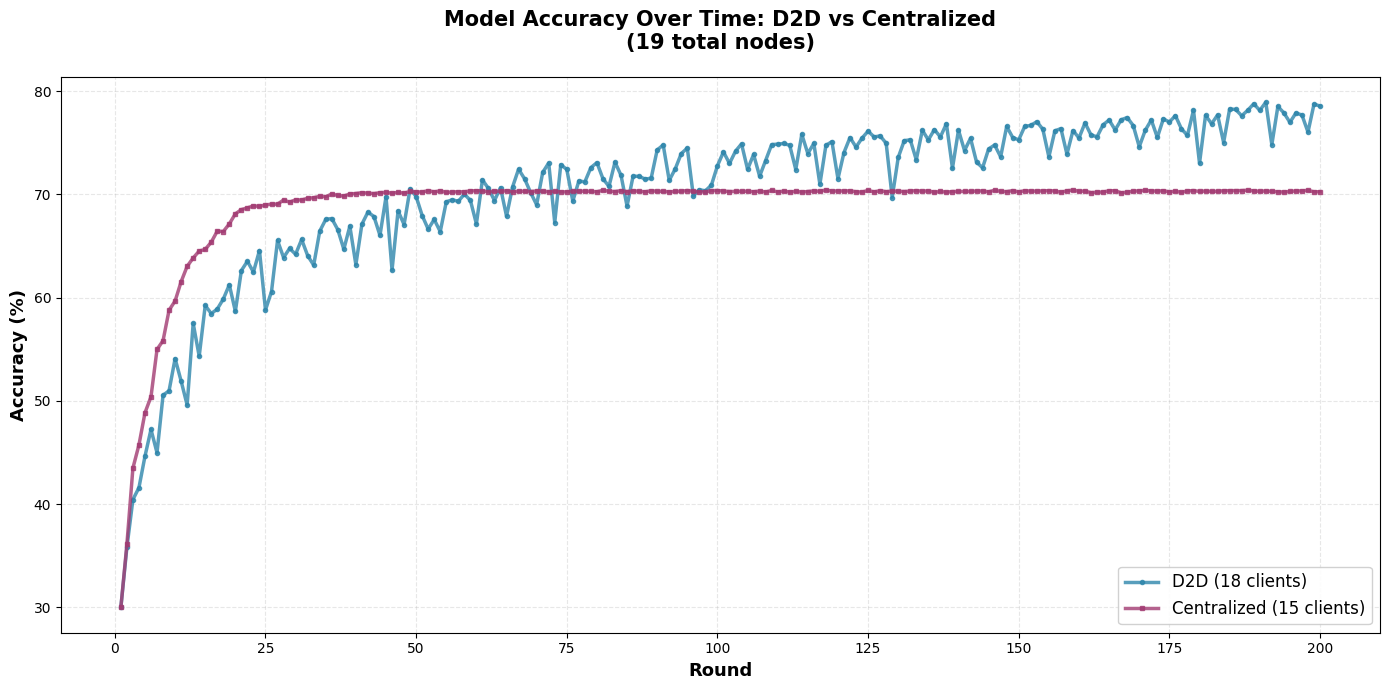


Creating comparison plot for scenarios with 37 total nodes
D2D:         2025-11-24 14:03 Centralized D2D 1 36 Offloading
Centralized: 2025-11-24 14:43 Centralized  6 30 Offloading

Comparison: 37 total nodes

D2D Architecture (36 clients):
  - Initial Accuracy: 26.52%
  - Final Accuracy:   73.97%
  - Max Accuracy:     75.65%
  - Total Rounds:     200

Centralized Architecture (30 clients):
  - Initial Accuracy: 26.07%
  - Final Accuracy:   64.42%
  - Max Accuracy:     64.44%
  - Total Rounds:     200

Difference (Centralized - D2D):
  - Final Accuracy:   -9.55%
  - Max Accuracy:     -11.21%


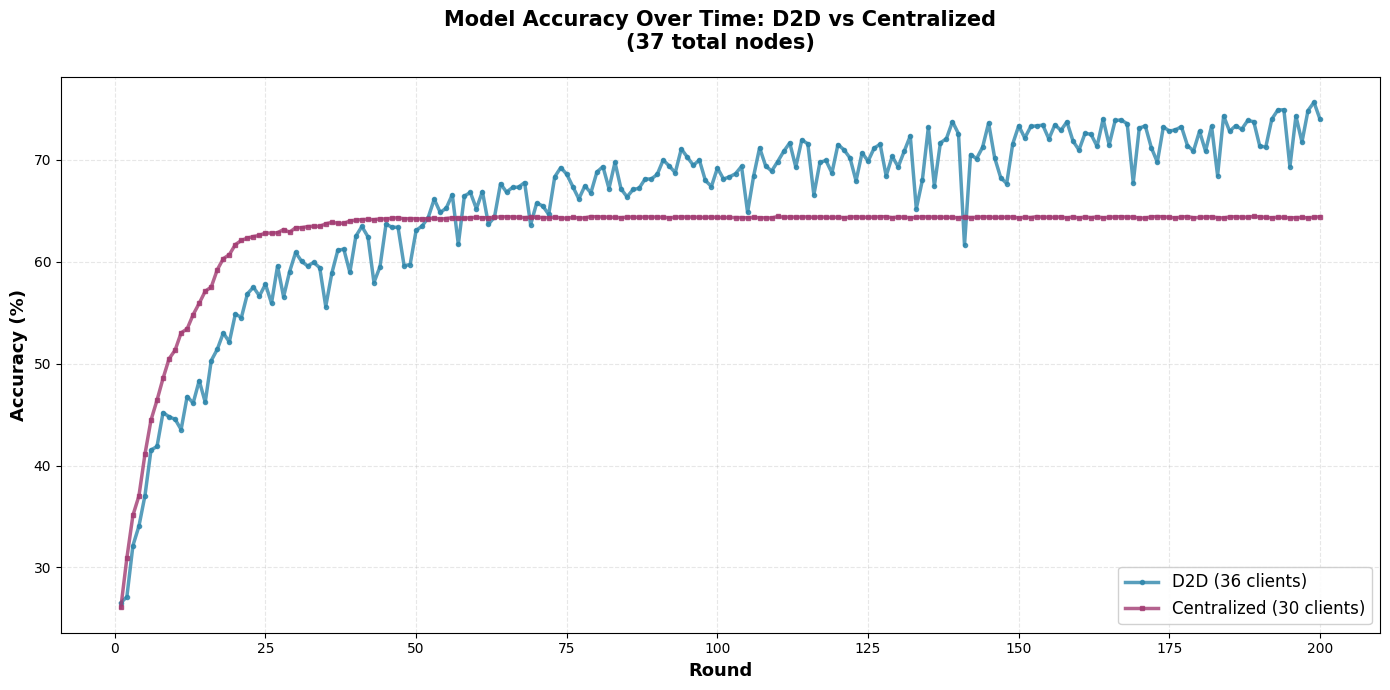


Created 2 comparison plot(s)


In [5]:
# Find and plot comparisons for matching scenarios (by total node count)
comparison_count = 0

for node_count, scen_list in sorted(scenarios_by_nodes.items()):
    # Find D2D and Centralized scenarios with same total node count
    d2d_scenarios = [s for s in scen_list if s['architecture'] == 'D2D']
    centralized_scenarios = [s for s in scen_list if s['architecture'] == 'Centralized']
    
    if d2d_scenarios and centralized_scenarios:
        # Plot comparison for first matching pair (can be extended for multiple)
        d2d_scenario = d2d_scenarios[0]
        centralized_scenario = centralized_scenarios[0]
        
        print(f"\n{'='*80}")
        print(f"Creating comparison plot for scenarios with {node_count} total nodes")
        print(f"{'='*80}")
        print(f"D2D:         {d2d_scenario['dir_name']}")
        print(f"Centralized: {centralized_scenario['dir_name']}")
        
        plot_comparison(d2d_scenario, centralized_scenario)
        comparison_count += 1

if comparison_count == 0:
    print("\n" + "="*80)
    print("No matching scenarios found!")
    print("="*80)
    print("\nTo create a comparison, you need scenarios with:")
    print("  - Same total node count")
    print("  - One with D2D architecture")
    print("  - One with Centralized architecture")
    print("\nCurrent scenarios:")
    for scenario in scenarios:
        print(f"  - {scenario['architecture']:12s} | {scenario['total_nodes']:2d} nodes | {scenario['device_count']:2d} clients")
else:
    print(f"\n{'='*80}")
    print(f"Created {comparison_count} comparison plot(s)")
    print(f"{'='*80}")


In [6]:
# Plot individual scenarios that don't have matches (optional)
def plot_individual_scenario(scenario):
    """Plot accuracy over time for a single scenario."""
    
    # Load data
    data = load_scenario_data(scenario['csv_file'])
    
    # Create figure
    plt.figure(figsize=(14, 7))
    
    # Plot
    color = '#2E86AB' if scenario['architecture'] == 'D2D' else '#A23B72'
    plt.plot(data['Round'], data['Accuracy (%)'], 
             marker='o', markersize=3, linewidth=2.5, 
             label=f"{scenario['architecture']} ({scenario['device_count']} clients, {scenario['total_nodes']} nodes)", 
             color=color, alpha=0.8)
    
    # Formatting
    plt.xlabel('Round', fontsize=13, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
    plt.title(f"Model Accuracy Over Time: {scenario['architecture']}\n({scenario['device_count']} clients, {scenario['total_nodes']} total nodes)", 
              fontsize=15, fontweight='bold', pad=20)
    plt.legend(fontsize=12, loc='lower right', framealpha=0.9)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Display statistics
    print(f"\n{'='*70}")
    print(f"{scenario['architecture']} - {scenario['total_nodes']} nodes ({scenario['device_count']} clients)")
    print(f"{'='*70}")
    print(f"  - Initial Accuracy: {data['Accuracy (%)'].iloc[0]:.2f}%")
    print(f"  - Final Accuracy:   {data['Accuracy (%)'].iloc[-1]:.2f}%")
    print(f"  - Max Accuracy:     {data['Accuracy (%)'].max():.2f}%")
    print(f"  - Total Rounds:     {len(data)}")
    print(f"  - Directory:        {scenario['dir_name']}")
    
    plt.show()

# Optionally plot individual scenarios (uncomment to enable)
# print("\n" + "="*80)
# print("Individual Scenario Plots")
# print("="*80)
# for scenario in scenarios:
#     plot_individual_scenario(scenario)


In [6]:
# Function to plot comparison over time (cumulative training time)
def plot_comparison_over_time(d2d_scenario, centralized_scenario):
    """Plot accuracy over cumulative time comparison between D2D and Centralized architectures."""
    
    # Load data
    d2d_data = load_scenario_data(d2d_scenario['csv_file'])
    centralized_data = load_scenario_data(centralized_scenario['csv_file'])
    
    # Calculate cumulative time
    d2d_data['Cumulative Time (s)'] = d2d_data['Training Time (s)'].cumsum()
    centralized_data['Cumulative Time (s)'] = centralized_data['Training Time (s)'].cumsum()
    
    # Convert to minutes for better readability
    d2d_data['Cumulative Time (min)'] = d2d_data['Cumulative Time (s)'] / 60
    centralized_data['Cumulative Time (min)'] = centralized_data['Cumulative Time (s)'] / 60
    
    # Create figure
    plt.figure(figsize=(14, 7))
    
    # Plot D2D
    plt.plot(d2d_data['Cumulative Time (min)'], d2d_data['Accuracy (%)'], 
             marker='o', markersize=3, linewidth=2.5, 
             label=f"D2D ({d2d_scenario['device_count']} clients)", 
             color='#2E86AB', alpha=0.8)
    
    # Plot Centralized
    plt.plot(centralized_data['Cumulative Time (min)'], centralized_data['Accuracy (%)'], 
             marker='s', markersize=3, linewidth=2.5,
             label=f"Centralized ({centralized_scenario['device_count']} clients)", 
             color='#A23B72', alpha=0.8)
    
    # Formatting
    plt.xlabel('Cumulative Training Time (minutes)', fontsize=13, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
    plt.title(f'Model Accuracy Over Time: D2D vs Centralized\n({d2d_scenario["total_nodes"]} total nodes)', 
              fontsize=15, fontweight='bold', pad=20)
    plt.legend(fontsize=12, loc='lower right', framealpha=0.9)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Display time statistics
    print(f"\n{'='*70}")
    print(f"Time-based Comparison: {d2d_scenario['total_nodes']} total nodes")
    print(f"{'='*70}")
    print(f"\nD2D Architecture ({d2d_scenario['device_count']} clients):")
    print(f"  - Total Training Time:     {d2d_data['Cumulative Time (min)'].iloc[-1]:.2f} minutes ({d2d_data['Cumulative Time (s)'].iloc[-1]:.2f} seconds)")
    print(f"  - Average Time per Round:  {d2d_data['Training Time (s)'].mean():.2f} seconds")
    print(f"  - Final Accuracy:          {d2d_data['Accuracy (%)'].iloc[-1]:.2f}%")
    
    print(f"\nCentralized Architecture ({centralized_scenario['device_count']} clients):")
    print(f"  - Total Training Time:     {centralized_data['Cumulative Time (min)'].iloc[-1]:.2f} minutes ({centralized_data['Cumulative Time (s)'].iloc[-1]:.2f} seconds)")
    print(f"  - Average Time per Round:  {centralized_data['Training Time (s)'].mean():.2f} seconds")
    print(f"  - Final Accuracy:          {centralized_data['Accuracy (%)'].iloc[-1]:.2f}%")
    
    time_diff = centralized_data['Cumulative Time (s)'].iloc[-1] - d2d_data['Cumulative Time (s)'].iloc[-1]
    time_diff_pct = (time_diff / d2d_data['Cumulative Time (s)'].iloc[-1]) * 100
    print(f"\nTime Difference (Centralized - D2D):")
    print(f"  - Total Time Difference:   {time_diff:+.2f} seconds ({time_diff/60:+.2f} minutes)")
    print(f"  - Relative Difference:     {time_diff_pct:+.2f}%")
    
    plt.show()



ACCURACY OVER TIME (Cumulative Training Time)

Creating time-based comparison plot for scenarios with 19 total nodes
D2D:         2025-11-24 13:06 Centralized D2D 1 18 Offloading
Centralized: 2025-11-24 13:32 Centralized  3 15 Offloading

Time-based Comparison: 19 total nodes

D2D Architecture (18 clients):
  - Total Training Time:     13.98 minutes (838.99 seconds)
  - Average Time per Round:  4.19 seconds
  - Final Accuracy:          78.55%

Centralized Architecture (15 clients):
  - Total Training Time:     17.27 minutes (1035.91 seconds)
  - Average Time per Round:  5.18 seconds
  - Final Accuracy:          70.26%

Time Difference (Centralized - D2D):
  - Total Time Difference:   +196.92 seconds (+3.28 minutes)
  - Relative Difference:     +23.47%


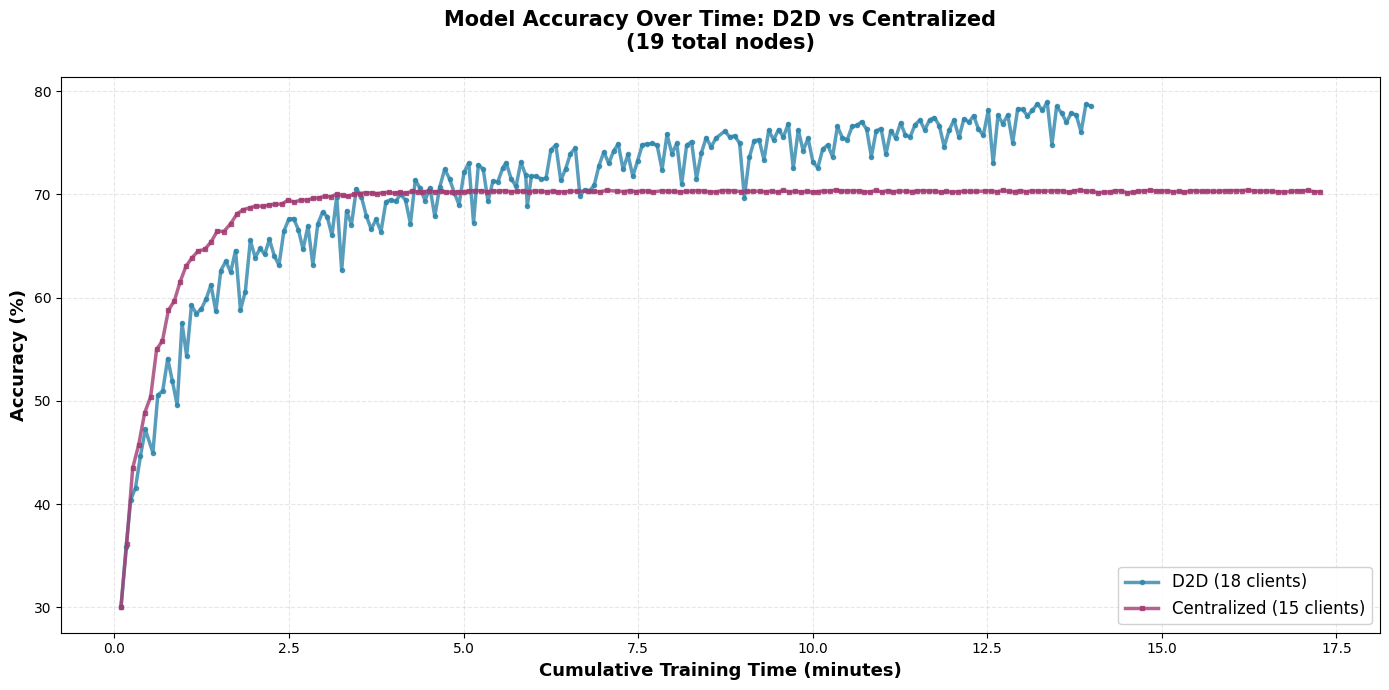


Creating time-based comparison plot for scenarios with 37 total nodes
D2D:         2025-11-24 14:03 Centralized D2D 1 36 Offloading
Centralized: 2025-11-24 14:43 Centralized  6 30 Offloading

Time-based Comparison: 37 total nodes

D2D Architecture (36 clients):
  - Total Training Time:     13.53 minutes (811.74 seconds)
  - Average Time per Round:  4.06 seconds
  - Final Accuracy:          73.97%

Centralized Architecture (30 clients):
  - Total Training Time:     18.67 minutes (1119.95 seconds)
  - Average Time per Round:  5.60 seconds
  - Final Accuracy:          64.42%

Time Difference (Centralized - D2D):
  - Total Time Difference:   +308.21 seconds (+5.14 minutes)
  - Relative Difference:     +37.97%


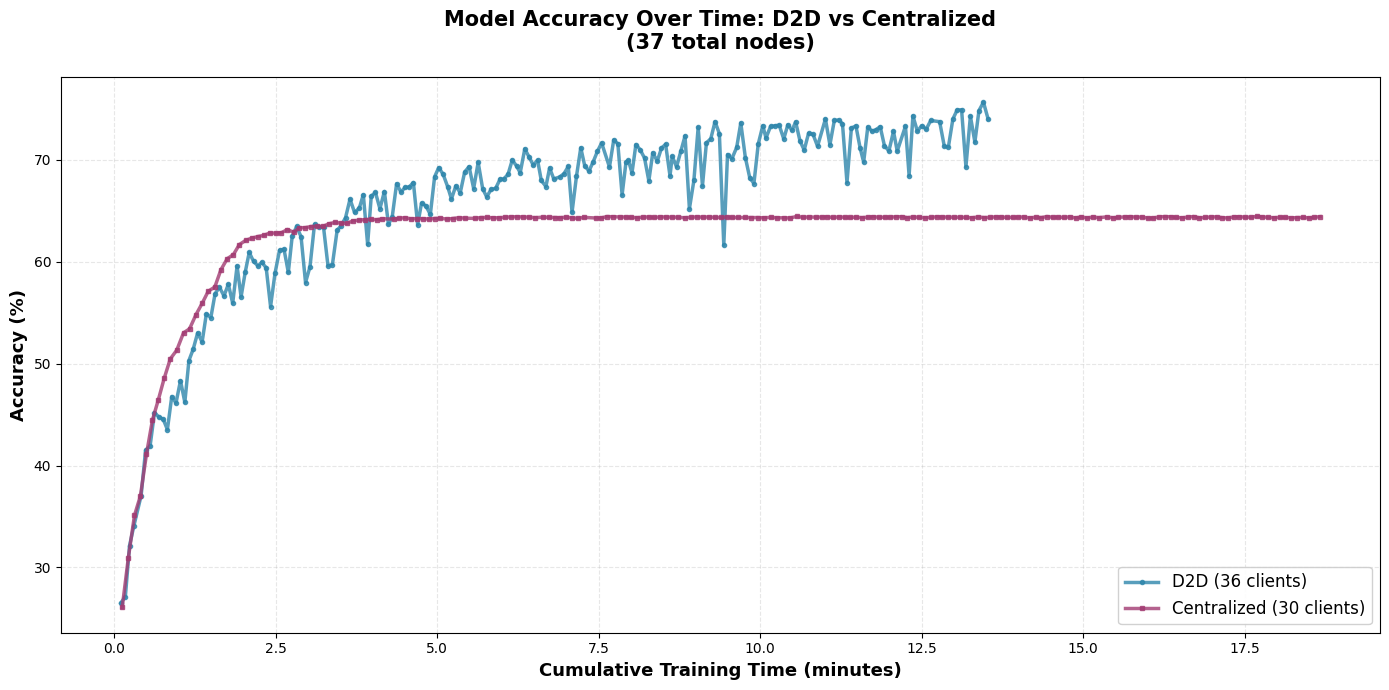


Created 2 time-based comparison plot(s)


In [7]:
# Create time-based comparison plots for matching scenarios
print("\n" + "="*80)
print("ACCURACY OVER TIME (Cumulative Training Time)")
print("="*80)

comparison_count = 0

for node_count, scen_list in sorted(scenarios_by_nodes.items()):
    # Find D2D and Centralized scenarios with same total node count
    d2d_scenarios = [s for s in scen_list if s['architecture'] == 'D2D']
    centralized_scenarios = [s for s in scen_list if s['architecture'] == 'Centralized']
    
    if d2d_scenarios and centralized_scenarios:
        # Plot comparison for first matching pair
        d2d_scenario = d2d_scenarios[0]
        centralized_scenario = centralized_scenarios[0]
        
        print(f"\n{'='*80}")
        print(f"Creating time-based comparison plot for scenarios with {node_count} total nodes")
        print(f"{'='*80}")
        print(f"D2D:         {d2d_scenario['dir_name']}")
        print(f"Centralized: {centralized_scenario['dir_name']}")
        
        plot_comparison_over_time(d2d_scenario, centralized_scenario)
        comparison_count += 1

if comparison_count > 0:
    print(f"\n{'='*80}")
    print(f"Created {comparison_count} time-based comparison plot(s)")
    print(f"{'='*80}")
